In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from evals.text_similarity import TextSimilarity
import os
import pandas as pd
import pprint
import json
from data.utils import load_data, save_data, append_data, extract_answer
from inference.clients.openrouter import OpenRouterClient
from tqdm import tqdm
from inference.models import MODELS, MODEL_LABEL_MAP, DATASETS
os.chdir(os.environ.get("PROJ_DIR"))

## Check provider works

In [3]:
model="openai/gpt-4o-mini"
orc = OpenRouterClient(model=model, max_tokens=1000)
query = "Guess the most likely meaning of the pseudoword 'trendipitious'."
resp = orc.query(query)
response_json = json.loads(resp.model_dump_json() if resp else '{}')
model_response = response_json.get('choices', [{}])[0].get('message', '').get('content', '') if response_json else ''
print(model_response)


# Output: 'The pseudoword "trendipitious" seems to be a blend of "trend" and possibly "expeditious" or "expeditiousness." Based on this, one could infer that "trendipitious" might refer to something that is related to or characterized by trends in a quick or efficient manner. It could describe a phenomenon, behavior, or product that rapidly aligns with or capitalizes on current trends.'

The pseudoword "trendipitious" seems to be a blend of "trend" and possibly "expeditious" or "propitious." Based on this, one could infer that "trendipitious" might refer to something that is favorable or advantageous in relation to current trends, or perhaps something that facilitates or accelerates the adoption of trends. It could imply a quality or characteristic that enhances the likelihood of a trend being successful or popular.


## Check similarity computation works

In [4]:
from evals.text_similarity import TextSimilarity
s = TextSimilarity('ngram_overlap', n=2, measure='dice')
s.compute_pairwise_sim('biology', 'biologist')            # 0.714
s.aggregate_similarity(['biology','biologist','zebra'], ['mean','max'])
# {'mean': 0.238, 'max': 0.714}

{'mean': 0.2380952380952381, 'max': 0.7142857142857143}

## Dataset-level tests

### Testing prompt builder

In [5]:
from inference.build_prompts import PromptBuilder

pb = PromptBuilder(
    user_prompt_path="data/prompt_templates/tasks/guess_meaning/p1/user.txt",
    system_prompt_path="data/prompt_templates/tasks/guess_meaning/p1/system.txt",
    data_path="data/datasets/sample-10-real.csv",
)
df = pb.build_prompt_dataset()
save_data(df, "data/prompts/guess_meaning/p1/sample-10-real.jsonl")

In [6]:
df.head()

,word,messages
0,correspondence,"[{'role': 'system', 'content': 'You are a scho..."
1,decrement,"[{'role': 'system', 'content': 'You are a scho..."
2,depository,"[{'role': 'system', 'content': 'You are a scho..."
3,ransom,"[{'role': 'system', 'content': 'You are a scho..."
4,showing,"[{'role': 'system', 'content': 'You are a scho..."


### Prompt models with constructed prompts
Use data saved in "data/prompts/guess_meaning/p1/sample-10.jsonl".

In [4]:
def query_model_on_dataset(
        df, 
        model="openai/gpt-4o-mini", 
        provider="openrouter",
        output_path_fmt = "results/{model}/sample-10/model_outputs_df.jsonl",
        response_dir_fmt = "responses/{model}/sample-10"
    ):

    if provider == "openrouter":
        orc = OpenRouterClient(model=model, max_tokens=2000)

    response_dir = response_dir_fmt.format(model=model)
    model_outputs_df_path = output_path_fmt.format(model=model)
    os.makedirs(response_dir, exist_ok=True)

    processed_words = load_data(model_outputs_df_path).word.tolist() if os.path.exists(model_outputs_df_path) else []

    df_new = df[~df['word'].isin(processed_words)]  # Filter out already processed words
    if len(df_new) == 0: 
        print(f"No words remaining to test {model} on.")
        return 0
    
    print(f"Total words remaining to process: {len(df_new)}")
    print(f"Responses will be saved to: {response_dir}")
    model_outputs_df = []

    for row in tqdm(df_new.itertuples(), total=len(df_new)):
        word = row.word
        messages = row.messages
        print(f"Processing word: {word}")

        response = orc.query(messages=messages)
        response_json = json.loads(response.model_dump_json() if response else '{}')
        model_response = response_json.get('choices', [{}])[0].get('message', '').get('content', '') if response_json else ''

        response_fname = os.path.join(response_dir, f"{word}.jsonl")

        try:
            with open(response_fname, "a", encoding="utf-8") as file:
                file.write(json.dumps(response_json) + "\n")
                
        except Exception as e:
            print(f"Error saving response: {e}")

        model_outputs_df.append({
            "model": model,
            "word": word,
            "model_response": model_response
        })
        if len(model_outputs_df) % 5 == 0:
            print(f"Processed {len(model_outputs_df)} words. Saving intermediate results.")
            append_data(pd.DataFrame(model_outputs_df), model_outputs_df_path)
            model_outputs_df = []  # Clear the list after saving

    if len(model_outputs_df) > 0:  # Save any remaining data
        append_data(pd.DataFrame(model_outputs_df), model_outputs_df_path)
    return model_outputs_df



In [5]:
from inference.models import MODELS

# model="openai/gpt-4o-mini"
model="anthropic/claude-haiku-4.5"

for dataset_name in DATASETS.keys():
    df = load_data(f"data/prompts/guess_meaning/p1/{dataset_name}.jsonl")
    for model in MODELS:
        model_outputs_df = query_model_on_dataset(
            df, 
            model=model, 
            provider="openrouter",
            output_path_fmt = f"results/{{model}}/{dataset_name}/model_outputs_df.jsonl",
            response_dir_fmt = f"responses/{{model}}/{dataset_name}"
    )

No words remaining to test openai/gpt-4o-mini on.
No words remaining to test openai/gpt-5-mini on.
Total words remaining to process: 10
Responses will be saved to: responses/openai/gpt-4.1-mini/sample-10


  0%|          | 0/10 [00:00<?, ?it/s]

Processing word: corpersonance


 10%|█         | 1/10 [00:02<00:23,  2.63s/it]

Processing word: decament


...

Processing word: defense


 90%|█████████ | 9/10 [00:17<00:01,  1.90s/it]

Processing word: discovering


100%|██████████| 10/10 [00:18<00:00,  1.88s/it]

Processed 5 words. Saving intermediate results.
No words remaining to test openai/gpt-5.4-mini on.


### Process responses

In [6]:
def process_model_results(MODELS, results_path):
    """
        Computes similarity between outputs from model pairs
    """
    stacked_df = pd.DataFrame()

    for model in MODELS:
        model_outputs_df_path = results_path.format(model=model)
        if os.path.exists(model_outputs_df_path):
            model_outputs_df = load_data(model_outputs_df_path)
            print(f"Loaded results for model: {model}")
            stacked_df = pd.concat([stacked_df, model_outputs_df], ignore_index=True)
        else:
            print(f"No results found for model: {model}")

    # convert to wide format for easier comparison
    stacked_df["model_meaning"] = stacked_df["model_response"].apply(lambda x: extract_answer(x))

    proc_df = (
        stacked_df.pivot(index='word', columns='model', values='model_meaning')
        .reset_index()
        .rename_axis(None, axis=1)
    )
    

    return proc_df

In [7]:
for dataset_name in DATASETS.keys():
    results_path = f"results/{{model}}/{dataset_name}/model_outputs_df.jsonl"
    processed_results_df = process_model_results(MODELS, results_path)
    save_data(processed_results_df, f"results/{dataset_name}/processed.jsonl")

Loaded results for model: openai/gpt-4o-mini
Loaded results for model: openai/gpt-5-mini
Loaded results for model: openai/gpt-4.1-mini
Loaded results for model: openai/gpt-5.4-mini
Loaded results for model: openai/gpt-4o-mini
Loaded results for model: openai/gpt-5-mini
Loaded results for model: openai/gpt-4.1-mini
Loaded results for model: openai/gpt-5.4-mini


In [3]:
def compute_sims(ts, df, sim_type): 
    all_pairs_sims = pd.DataFrame(columns=["sim_type", "model_pair", "word_string", "sim"])
    sims = ts.compute_pairwise_sim_df(df, key_col="word", model_cols=MODELS)
    for model_pair, pair_sims in sims.items():
        df_model = pd.DataFrame.from_dict(pair_sims, orient="index", columns=['sim']).reset_index().rename(columns={"index": "word_string"})
        df_model["model_pair"] = [model_pair] * len(df_model)
        df_model["sim_type"] = sim_type
        all_pairs_sims = pd.concat([all_pairs_sims, df_model])
    return all_pairs_sims


In [4]:
ts_cos = TextSimilarity("embedding_cosine")
ts_3gm = TextSimilarity("ngram_overlap", n=3, level="char")  

/opt/anaconda3/envs/syngeny-env/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 10177.95it/s]


In [5]:
merged_results = pd.DataFrame(columns=["word_string", "model_pair", "sim_type", "sim", "word_source"])

sim_metrics = [
    {"3-gram": ts_3gm},
    {"cos": ts_cos}
]

for metric_dict in sim_metrics:
    metric, ts = next(iter(metric_dict.items()))
    for dataset_name, word_source in DATASETS.items():
        path_to_proc_results = f"results/{dataset_name}/processed.jsonl"
        processed_results_df = load_data(path_to_proc_results)
        sims_df = compute_sims(ts, processed_results_df, metric)
        sims_df["word_source"] = word_source
        merged_results = pd.concat([merged_results, sims_df], ignore_index=True)


In [6]:
results = merged_results.sort_values(["word_string", "model_pair", "sim_type"])
results.word_source.value_counts()


word_source
Fake    120
Real    120
Name: count, dtype: int64

In [7]:
mean_df = results[["model_pair", "sim_type", "word_source", "sim"]].groupby(["model_pair", "sim_type", "word_source"]).agg(mean_sim = ('sim', "mean")).reset_index()

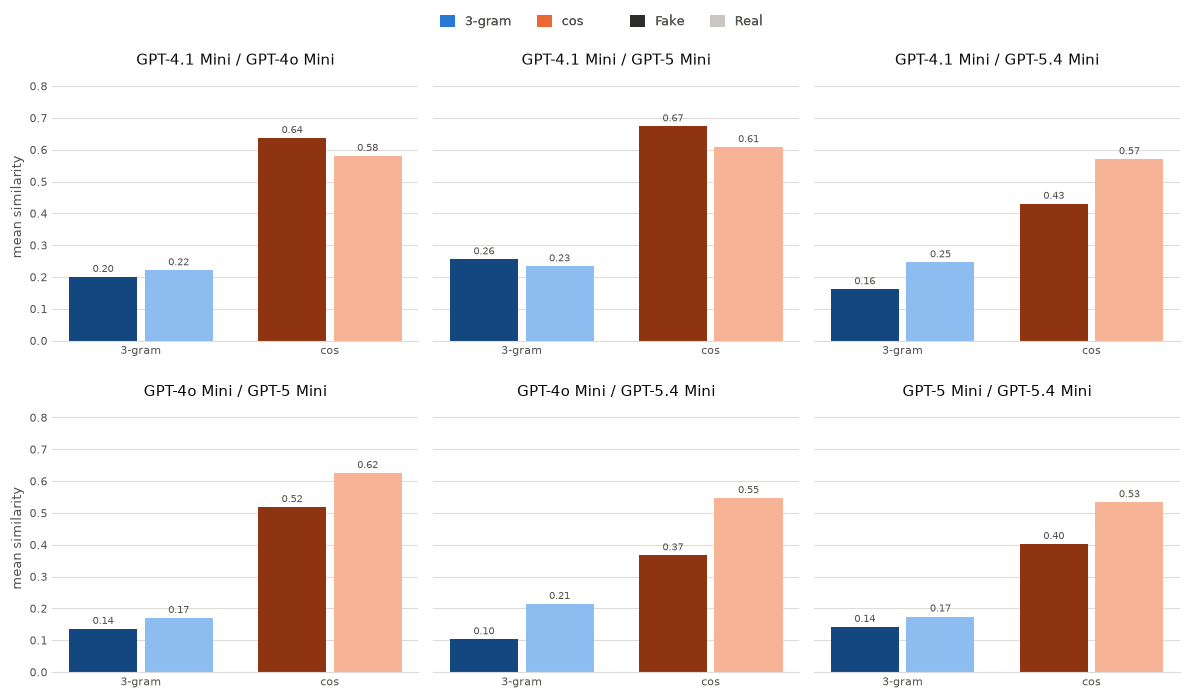

In [8]:
# from src.plotting.plot_mean_sim import *

from src.plotting.plot_mean_sim import plot_mean_sim
fig = plot_mean_sim(mean_df)   # one subplot per word_source


In [9]:
MODELS

['openai/gpt-4o-mini',
 'openai/gpt-5-mini',
 'openai/gpt-4.1-mini',
 'openai/gpt-5.4-mini']

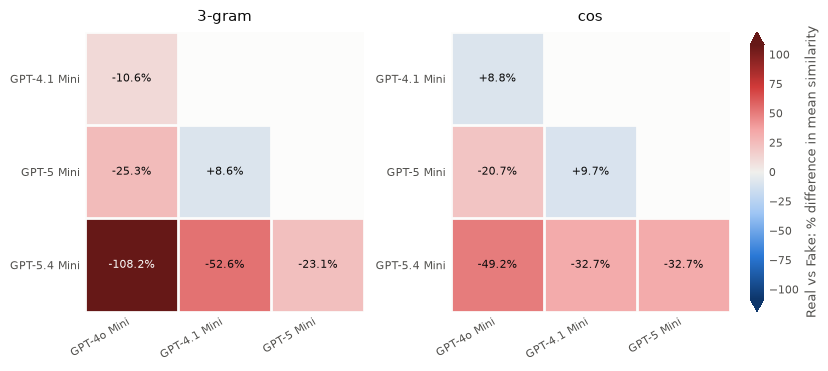

In [11]:
# from src.plotting.plot_mean_sim import *

ordered_models = [
    'openai/gpt-4o-mini', # gpt-4o-mini-2024-07-18
    'openai/gpt-4.1-mini', # gpt-4.1-mini-2025-04-14
    # 'openai/gpt-5-nano', # gpt-5-nano-2025-08-07
    'openai/gpt-5-mini', # gpt-5-mini-2025-08-07
    # 'openai/gpt-5.2', # gpt-5.2-2025-12-11
    'openai/gpt-5.4-mini' # gpt-5.4-mini-2026-03-17
]

from src.plotting.plot_mean_sim import plot_real_fake_diff
fig = plot_real_fake_diff(mean_df, models=ordered_models)   # one subplot per word_source


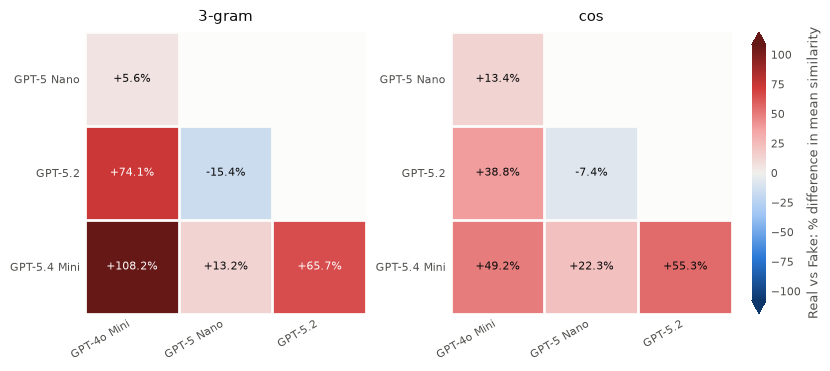

In [ ]:
# from src.plotting.plot_mean_sim import *

ordered_models = [
    'openai/gpt-4o-mini', # gpt-4o-mini-2024-07-18
    'openai/gpt-4.1-mini' # gpt-4.1-mini-2025-04-14
    # 'openai/gpt-5-nano', # gpt-5-nano-2025-08-07
    'openai/gpt-5-mini' # gpt-5-mini-2025-08-07
    # 'openai/gpt-5.2', # gpt-5.2-2025-12-11
    'openai/gpt-5.4-mini' # gpt-5.4-mini-2026-03-17


]

from src.plotting.plot_mean_sim import plot_real_fake_diff
fig = plot_real_fake_diff(mean_df, models=ordered_models)   # one subplot per word_source


In [ ]:
models=[]

array([frozenset({'openai/gpt-4o-mini', 'openai/gpt-5.2'}),
       frozenset({'openai/gpt-4o-mini', 'openai/gpt-5-nano'}),
       frozenset({'openai/gpt-4o-mini', 'openai/gpt-5.4-mini'}),
       frozenset({'openai/gpt-5.2', 'openai/gpt-5-nano'}),
       frozenset({'openai/gpt-5.4-mini', 'openai/gpt-5.2'}),
       frozenset({'openai/gpt-5.4-mini', 'openai/gpt-5-nano'})],
      dtype=object)